In [1]:
import oracledb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns 

In [2]:
conn_ibs = oracledb.connect(
    user="ibs",
    password="snap2025",
    host="10.7.9.3",
    port=1521,
    service_name="iabssnp"
)

conn_dwh = oracledb.connect(
    user='dwh',
    password='dwh',
    host='10.8.18.71',
    port=1521,
    service_name='dwhoradb'
)

# АКБ

In [3]:
msb_acb = pd.read_sql(
f"""SELECT DISTINCT rep_dt, client_code, 'МСБ' as segment
FROM finance.BRV_ACTIVE_ACCOUNTS_UL_90D_BXM_4 baaudb 
ORDER BY REP_DT
"""
, conn_dwh)
msb_acb

C:\Users\nzayniyev\AppData\Local\Temp\ipykernel_24752\2990208691.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  msb_acb = pd.read_sql(


,REP_DT,CLIENT_CODE,SEGMENT
0,2024-01-31,00226951,МСБ
1,2024-01-31,04552426,МСБ
2,2024-01-31,00902463,МСБ
3,2024-01-31,05443681,МСБ
4,2024-01-31,05553672,МСБ
...,...,...,...
1061487,2026-03-31,03825427,МСБ
1061488,2026-03-31,07122007,МСБ
1061489,2026-03-31,05651291,МСБ
1061490,2026-03-31,00514438,МСБ


In [4]:
msb_acb.rename(columns={'REP_DT': 'eomonth', 'CLIENT_CODE': 'client_code', 'SEGMENT': 'segment'}, inplace=True)

msb_acb["client_code"] = msb_acb['client_code'].astype(str).str.zfill(8)
msb_acb["eomonth"] = pd.to_datetime(msb_acb["eomonth"])

In [5]:
# msb_acb.to_csv(r'C:\Users\nzayniyev\Documents\сегментация\msb_acb.csv', index=False)

In [5]:
corp_acb = pd.read_sql(
f"""
SELECT REP_DT, CLIENT_CODE, 'КОРП' as segment FROM finance.corp_base
order by rep_dt
"""
, conn_dwh)
corp_acb

C:\Users\nzayniyev\AppData\Local\Temp\ipykernel_24752\2858950557.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  corp_acb = pd.read_sql(


,REP_DT,CLIENT_CODE,SEGMENT
0,2025-01-31,05666485,КОРП
1,2025-01-31,05680669,КОРП
2,2025-01-31,05677711,КОРП
3,2025-01-31,05675446,КОРП
4,2025-01-31,00645059,КОРП
...,...,...,...
30521,2026-03-31,07215904,КОРП
30522,2026-03-31,07196158,КОРП
30523,2026-03-31,05130832,КОРП
30524,2026-03-31,07098020,КОРП


In [6]:
corp_acb.rename(columns={'REP_DT': 'eomonth', 'CLIENT_CODE': 'client_code', 'SEGMENT': 'segment'}, inplace=True)

corp_acb["client_code"] = corp_acb['client_code'].astype(str).str.zfill(8)
corp_acb["eomonth"] = pd.to_datetime(corp_acb["eomonth"])

In [8]:
#corp_acb.to_csv(r'C:\Users\nzayniyev\Documents\сегментация\corp_acb.csv', index=False)

In [9]:
# table_name='yurik_client_code_old'

In [10]:
# client_codes = acb["client_code"].dropna().astype(str).unique().tolist()

# cursor = conn.cursor()

# try:
#     cursor.execute(f"""
#         CREATE TABLE {table_name} (
#             client_code varchar2(8)
#         )
#     """)
# except Exception as e:
#     print(e)
# else:
#     cursor.executemany(
#         f"INSERT INTO {table_name} (client_code) VALUES (:1)",
#         [(x,) for x in client_codes]
#     )
# conn.commit()

In [7]:
acb = (
    pd.concat([corp_acb, msb_acb], ignore_index=True)
    .sort_values(['eomonth', 'client_code'])
    .drop_duplicates(subset=['eomonth', 'client_code'], keep='first')
    .reset_index(drop=True)
)
acb.sort_values(['eomonth', 'client_code'], inplace=True)
acb

,eomonth,client_code,segment
0,2024-01-31,00000450,МСБ
1,2024-01-31,00010012,МСБ
2,2024-01-31,00010013,МСБ
3,2024-01-31,00010014,МСБ
4,2024-01-31,00010467,МСБ
...,...,...,...
1070026,2026-03-31,07434311,МСБ
1070027,2026-03-31,07434392,МСБ
1070028,2026-03-31,07434500,МСБ
1070029,2026-03-31,07434531,МСБ


In [8]:
client_base = pd.read_sql(
    """
    SELECT cc.code,
    cc."CONDITION",
    LAST_DAY(date_change_condition) AS eomonth
    FROM client_current cc
    WHERE cc.typeof NOT IN (08)
    -- AND NOT EXISTS (
    --  SELECT 1
    --  FROM client_current x
    --  WHERE x.code = cc.code
    --    AND x."CONDITION" = 'C'
    --    AND x.date_change_condition < DATE '2025-01-01')
    """, conn_ibs)

client_base

C:\Users\nzayniyev\AppData\Local\Temp\ipykernel_24752\1769311905.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  client_base = pd.read_sql(


,CODE,CONDITION,EOMONTH
0,00000062,A,2016-01-31
1,77000023,C,2015-08-31
2,00001111,A,2014-11-30
3,77000024,C,2019-06-30
4,00000800,A,2017-01-31
...,...,...,...
340903,00713886,C,2020-02-29
340904,05264688,A,2020-08-31
340905,00942723,C,2021-02-28
340906,05372046,C,2021-04-30


In [5]:
client_base = pd.read_sql(
    """
    SELECT cc.code,name, inn
    FROM client_current cc
    WHERE cc.typeof NOT IN (08)
    """, conn_ibs)

client_base.to_csv(r'C:\Users\nzayniyev\Documents\Scripts\Segmentation data for analysis\clients_name.csv', index=False)

C:\Users\nzayniyev\AppData\Local\Temp\ipykernel_29360\306277134.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  client_base = pd.read_sql(


In [ ]:
client_base

In [9]:
client_base.rename(columns={'CODE': 'client_code', 'EOMONTH': 'eomonth', 'CONDITION': 'is_closed'}, inplace=True)
client_base['is_closed'] = (client_base['is_closed'] != 'A').astype(int)
client_base['client_code'] = client_base['client_code'].astype(str).str.zfill(8)
client_base['eomonth'] = pd.to_datetime(client_base['eomonth'])
client_base.sort_values(['client_code', 'eomonth'], inplace=True)
client_base

,client_code,is_closed,eomonth
857,00000000,0,2004-02-29
144150,00000000,1,2014-11-30
100655,00000000,1,2016-05-31
211432,00000001,1,2024-07-31
238710,00000002,0,2019-09-30
...,...,...,...
340572,I0360646,1,2026-04-30
340573,I0360650,1,2026-04-30
340897,I0360653,1,2026-04-30
339311,I0360681,1,2026-04-30


In [10]:
acb = acb.merge(
    client_base[['client_code', 'eomonth', 'is_closed']].rename(
        columns={'eomonth': 'base_eomonth'}
    ),
    on='client_code',
    how='left'
)

# before switch date -> opposite, from switch date onward -> original
acb['is_closed'] = np.where(
    acb['eomonth'] < acb['base_eomonth'],
    1 - acb['is_closed'],
    acb['is_closed']
)

# optional: drop helper column
acb = acb.drop(columns='base_eomonth')
acb

,eomonth,client_code,segment,is_closed
0,2024-01-31,00000450,МСБ,0
1,2024-01-31,00010012,МСБ,0
2,2024-01-31,00010013,МСБ,0
3,2024-01-31,00010014,МСБ,0
4,2024-01-31,00010467,МСБ,0
...,...,...,...,...
1070026,2026-03-31,07434311,МСБ,0
1070027,2026-03-31,07434392,МСБ,0
1070028,2026-03-31,07434500,МСБ,0
1070029,2026-03-31,07434531,МСБ,0


In [11]:
acb.loc[
    (acb['eomonth'] == '2025-01-31') & (acb['is_closed'] == 1),
    'client_code'
].nunique()

2155

In [12]:
# full month grid
all_months = pd.date_range(acb['eomonth'].min(), acb['eomonth'].max(), freq='ME')
all_clients = acb['client_code'].unique()

grid = pd.MultiIndex.from_product(
    [all_clients, all_months],
    names=['client_code', 'eomonth']
).to_frame(index=False)

panel = grid.merge(acb, on=['client_code', 'eomonth'], how='left')
panel = panel.sort_values(['client_code', 'eomonth']).reset_index(drop=True)

panel['is_active'] = panel['segment'].notna()

g = panel.groupby('client_code')

panel['prev_active'] = g['is_active'].shift(1, fill_value=False)
panel['next_active'] = g['is_active'].shift(-1, fill_value=False)
panel['prev_segment'] = g['segment'].shift(1)
panel['next_segment'] = g['segment'].shift(-1)

# entry / exit episodes
panel['entry_flag'] = panel['is_active'] & (~panel['prev_active'])
panel['exit_flag'] = panel['is_active'] & (~panel['next_active'])

panel['entry_no'] = g['entry_flag'].cumsum()
panel['exit_no'] = g['exit_flag'].cumsum()

def get_status(row):
    if not row['is_active']:
        return np.nan
    
    #prefix = 'm_' if row['segment'] == 'МСБ' else 'k_'
    
    # # closed flags
    # if row['initially_closed'] == 1:
    #     return prefix + 'in_closed'
    # if row['is_closed'] == 1:
    #     return prefix + 'closed'

    # transfers
    if row['prev_active'] and row['segment'] != row['prev_segment']:
        return f"{row['prev_segment']}->{row['segment']}"
    
    # entries
    if row['entry_flag']:
        return ('entry' if row['entry_no'] == 1 else 're_entry')
    
    # exits
    if row['exit_flag']:
        return ('exit_ahd' if row['exit_no'] == 1 else 're_exit_ahd')
    
    return row['segment']

panel['status'] = panel.apply(get_status, axis=1)

panel.loc[
    panel['eomonth'].eq(panel['eomonth'].min()) &
    panel['status'].isin(['entry', 're_entry']),
    'status'
] = panel['segment']

panel.loc[
            panel['eomonth'].eq(panel['eomonth'].max()) &
            panel['status'].isin(['exit_ahd', 're_exit_ahd']),
            'status']= panel['segment']

result_acb = panel.loc[panel['is_active'], ['eomonth', 'client_code', 'segment', 'status','is_closed']].sort_values(['eomonth', 'client_code']).reset_index(drop=True).copy()
result_acb

,eomonth,client_code,segment,status,is_closed
0,2024-01-31,00000450,МСБ,МСБ,0.0
1,2024-01-31,00010012,МСБ,МСБ,0.0
2,2024-01-31,00010013,МСБ,МСБ,0.0
3,2024-01-31,00010014,МСБ,МСБ,0.0
4,2024-01-31,00010467,МСБ,МСБ,0.0
...,...,...,...,...,...
1070026,2026-03-31,07434311,МСБ,entry,0.0
1070027,2026-03-31,07434392,МСБ,entry,0.0
1070028,2026-03-31,07434500,МСБ,entry,0.0
1070029,2026-03-31,07434531,МСБ,entry,0.0


In [13]:
#filling missing values for exit_ahd and re_exit_ahd of КОРП segment
exit_mask = (
    (result_acb['segment'] == 'КОРП') &
    (result_acb['status'].isin(['exit_ahd', 're_exit_ahd']))
)

exit_rows = result_acb.loc[exit_mask].copy()

# change original exit statuses to КОРП
result_acb.loc[exit_mask, 'status'] = 'КОРП'

added_rows = []

for row in exit_rows.itertuples(index=False):
    client = row.client_code
    exit_month = row.eomonth

    future_rows = (
        result_acb[(result_acb['client_code'] == client) & (result_acb['eomonth'] > exit_month)]
        .sort_values('eomonth')
    )

    if future_rows.empty:
        missing_months = [m for m in all_months if m > exit_month]
    else:
        next_existing_month = future_rows['eomonth'].iloc[0]
        missing_months = [m for m in all_months if exit_month < m < next_existing_month]

    for i, m in enumerate(missing_months):
        added_rows.append({
            'eomonth': m,
            'client_code': client,
            'segment': 'МСБ',
            'status': 'КОРП->МСБ' if i == 0 else 'МСБ',
            'is_closed': 0
        })

added_df = pd.DataFrame(added_rows)

result_acb = (
    pd.concat([result_acb, added_df], ignore_index=True)
    .drop_duplicates(subset=['eomonth', 'client_code'], keep='first')
    .sort_values(['client_code', 'eomonth'])
    .reset_index(drop=True)
)

result_acb

,eomonth,client_code,segment,status,is_closed
0,2024-01-31,00000450,МСБ,МСБ,0.0
1,2024-07-31,00000450,МСБ,re_entry,0.0
2,2024-08-31,00000450,МСБ,МСБ,0.0
3,2024-09-30,00000450,МСБ,МСБ,0.0
4,2024-10-31,00000450,МСБ,МСБ,0.0
...,...,...,...,...,...
1072854,2026-03-31,07434311,МСБ,entry,0.0
1072855,2026-03-31,07434392,МСБ,entry,0.0
1072856,2026-03-31,07434500,МСБ,entry,0.0
1072857,2026-03-31,07434531,МСБ,entry,0.0


In [14]:
result_acb.groupby('segment')['status'].unique()


segment
КОРП                   [МСБ->КОРП, КОРП, entry, re_entry]
МСБ     [МСБ, re_entry, entry, exit_ahd, re_exit_ahd, ...
Name: status, dtype: object

# Оборот

In [15]:
turnover = pd.read_csv(r'C:\Users\nzayniyev\Documents\сегментация\Segmentation_all\turnover_all_v2.csv')
turnover

,CLIENT_CODE,EOMONTH,TURNOVER_JURIK
0,5390742,2024-01-31,6.065101e+07
1,5416620,2024-01-31,1.561326e+07
2,5437835,2024-01-31,5.239095e+06
3,5469697,2024-01-31,8.139506e+06
4,5471965,2024-01-31,1.070967e+08
...,...,...,...
905477,7419509,2026-03-31,1.000000e+03
905478,472460,2026-03-31,3.490320e+06
905479,4944333,2026-03-31,9.500000e+05
905480,4974375,2026-03-31,1.000000e+07


In [16]:
turnover.rename(columns={'CLIENT_CODE':'client_code', 'EOMONTH':'eomonth', 'TURNOVER_JURIK': 'turnover_bn'}, inplace=True)
turnover["client_code"] = turnover['client_code'].astype(str).str.zfill(8)
turnover["eomonth"] = pd.to_datetime(turnover["eomonth"])
turnover['turnover_bn'] = pd.to_numeric(turnover['turnover_bn'], errors='coerce', downcast='integer')
turnover['turnover_bn'] = (turnover['turnover_bn'] / 1_000_000_000).round(2)
turnover

c:\Users\nzayniyev\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\pandas\core\dtypes\cast.py:355: RuntimeWarning: invalid value encountered in cast
  new_result = trans(result).astype(dtype)


,client_code,eomonth,turnover_bn
0,05390742,2024-01-31,0.06
1,05416620,2024-01-31,0.02
2,05437835,2024-01-31,0.01
3,05469697,2024-01-31,0.01
4,05471965,2024-01-31,0.11
...,...,...,...
905477,07419509,2026-03-31,0.00
905478,00472460,2026-03-31,0.00
905479,04944333,2026-03-31,0.00
905480,04974375,2026-03-31,0.01


In [24]:
merged_df = pd.merge(result_acb, turnover, how='left', on=['eomonth', 'client_code'])
merged_df["turnover_bn"] = merged_df["turnover_bn"].fillna(0)
merged_df.sort_values(["client_code", "eomonth"], inplace=True)

In [25]:
def add_full_months(g):
    client = g.name

    full_idx = pd.date_range(
        start=g["eomonth"].min(),
        end=g["eomonth"].max(),
        freq="ME"
    )

    g = (
        g.set_index("eomonth")
         .reindex(full_idx)
         .rename_axis("eomonth")
         .reset_index()
    )

    g["client_code"] = client
    g["turnover_bn"] = g["turnover_bn"].fillna(0)

    return g

In [26]:
merged_df = (
    merged_df.groupby("client_code", group_keys=False)
    .apply(add_full_months)
    .reset_index(drop=True)
)

# number of available months since first observed month for each client
merged_df["months_available"] = merged_df.groupby("client_code").cumcount() + 1

# rolling sum for up to last 12 months
rolling_sum = (
    merged_df.groupby("client_code")["turnover_bn"]
    .transform(lambda s: s.rolling(12, min_periods=1).sum())
)

# annualize when history is shorter than 12 months
merged_df["turnover_y_bn"] = (
    rolling_sum * 12 / merged_df["months_available"].clip(upper=12)
).round(2)

merged_df = merged_df[[
    'eomonth',
    'client_code',
    'segment',
    'status',
    'is_closed',
    'turnover_bn',
    'turnover_y_bn'
]].reset_index(drop=True)

merged_df

,eomonth,client_code,segment,status,is_closed,turnover_bn,turnover_y_bn
0,2024-01-31,00000450,МСБ,МСБ,0.0,0.00,0.00
1,2024-02-29,00000450,NaN,NaN,NaN,0.00,0.00
2,2024-03-31,00000450,NaN,NaN,NaN,0.00,0.00
3,2024-04-30,00000450,NaN,NaN,NaN,0.00,0.00
4,2024-05-31,00000450,NaN,NaN,NaN,0.00,0.00
...,...,...,...,...,...,...,...
1393693,2026-03-31,07434311,МСБ,entry,0.0,0.00,0.00
1393694,2026-03-31,07434392,МСБ,entry,0.0,0.02,0.24
1393695,2026-03-31,07434500,МСБ,entry,0.0,0.01,0.12
1393696,2026-03-31,07434531,МСБ,entry,0.0,0.00,0.00


In [27]:
merged_df[merged_df['client_code']=='04919515'].sort_values('eomonth')

,eomonth,client_code,segment,status,is_closed,turnover_bn,turnover_y_bn
648525,2024-01-31,04919515,МСБ,МСБ,0.0,2.35,28.20
648526,2024-02-29,04919515,NaN,NaN,NaN,0.00,14.10
648527,2024-03-31,04919515,NaN,NaN,NaN,0.00,9.40
648528,2024-04-30,04919515,NaN,NaN,NaN,0.00,7.05
648529,2024-05-31,04919515,NaN,NaN,NaN,0.00,5.64
648530,2024-06-30,04919515,NaN,NaN,NaN,0.00,4.70
648531,2024-07-31,04919515,МСБ,re_entry,0.0,13.38,26.97
648532,2024-08-31,04919515,МСБ,МСБ,0.0,15.88,47.42
648533,2024-09-30,04919515,МСБ,МСБ,0.0,4.09,47.60
648534,2024-10-31,04919515,МСБ,МСБ,0.0,6.94,51.17


In [28]:
merged_df = merged_df[merged_df['eomonth']>'2024-12-31']
merged_df.loc[
            merged_df['eomonth'].eq(merged_df['eomonth'].min()) &
            merged_df['status'].isin(['entry', 're_entry', 'МСБ->КОРП']),
            'status'] = merged_df['segment']
merged_df.loc[
            merged_df['eomonth'].eq(merged_df['eomonth'].max()) &
            merged_df['status'].isin(['exit_ahd', 're_exit_ahd']),
            'status']= merged_df['segment']
merged_df.sort_values(['eomonth', 'client_code'], inplace=True)
merged_df

,eomonth,client_code,segment,status,is_closed,turnover_bn,turnover_y_bn
12,2025-01-31,00000450,МСБ,МСБ,0.0,0.00,0.86
33,2025-01-31,00009002,МСБ,re_exit_ahd,0.0,0.00,0.00
54,2025-01-31,00010012,МСБ,МСБ,0.0,0.00,0.00
81,2025-01-31,00010013,МСБ,МСБ,0.0,0.00,0.00
108,2025-01-31,00010014,МСБ,МСБ,0.0,0.00,0.00
...,...,...,...,...,...,...,...
1393693,2026-03-31,07434311,МСБ,entry,0.0,0.00,0.00
1393694,2026-03-31,07434392,МСБ,entry,0.0,0.02,0.24
1393695,2026-03-31,07434500,МСБ,entry,0.0,0.01,0.12
1393696,2026-03-31,07434531,МСБ,entry,0.0,0.00,0.00


In [24]:
# #full grid to detect in_active clients
# tmp = merged_df.copy()
# tmp['eomonth'] = pd.to_datetime(tmp['eomonth'])

# all_months = pd.date_range(tmp['eomonth'].min(), tmp['eomonth'].max(), freq='ME')
# all_clients = tmp['client_code'].unique()

# grid = pd.MultiIndex.from_product(
#     [all_months, all_clients],
#     names=['eomonth', 'client_code']
# ).to_frame(index=False)

# full = (
#     grid.merge(tmp, on=['eomonth', 'client_code'], how='left')
#         .sort_values(['client_code', 'eomonth'])
#         .reset_index(drop=True)
# )

# # fill segment inside each client
# full['segment'] = full.groupby('client_code')['segment'].transform(lambda s: s.ffill().bfill())

# # mark rows that were missing in original data
# miss = full['status'].isna()

# # fill inactive rows
# full.loc[miss, 'status'] = np.where(
#     full.loc[miss, 'segment'].eq('МСБ'),
#     'm_inactive',
#     'k_inactive'
# )

# full.loc[miss, ['is_closed', 'initially_closed','turnover_bn', 'turnover_y_bn']] = 0

# full

# Класс кредита

In [29]:
credit_class = pd.read_csv(r'C:\Users\nzayniyev\Documents\сегментация\Segmentation_all\credit_class_all_v2.csv')
credit_class

,CLIENT_CODE,EOMONTH,CREDIT_CLASS
0,100001,2025-01-31,1
1,101044,2025-01-31,1
2,101163,2025-01-31,4
3,101508,2025-01-31,2
4,103353,2025-01-31,3
...,...,...,...
154574,7426957,2026-03-31,1
154575,7427649,2026-03-31,1
154576,7427680,2026-03-31,1
154577,7428711,2026-03-31,1


In [30]:
credit_class.rename(columns={'CLIENT_CODE':'client_code', 'EOMONTH': 'eomonth','CREDIT_CLASS': 'credit_class'}, inplace=True)

credit_class["client_code"] = credit_class['client_code'].astype(str).str.zfill(8)
credit_class["eomonth"] = pd.to_datetime(credit_class["eomonth"])
credit_class['credit_class'] = pd.to_numeric(credit_class['credit_class'], errors='coerce', downcast='integer')

In [31]:
merged_df = pd.merge(merged_df, credit_class, how='left', on=['eomonth', 'client_code'])
merged_df['credit_class'] = merged_df['credit_class'].fillna(0)
merged_df

,eomonth,client_code,segment,status,is_closed,turnover_bn,turnover_y_bn,credit_class
0,2025-01-31,00000450,МСБ,МСБ,0.0,0.00,0.86,0.0
1,2025-01-31,00009002,МСБ,re_exit_ahd,0.0,0.00,0.00,0.0
2,2025-01-31,00010012,МСБ,МСБ,0.0,0.00,0.00,0.0
3,2025-01-31,00010013,МСБ,МСБ,0.0,0.00,0.00,0.0
4,2025-01-31,00010014,МСБ,МСБ,0.0,0.00,0.00,0.0
...,...,...,...,...,...,...,...,...
842761,2026-03-31,07434311,МСБ,entry,0.0,0.00,0.00,0.0
842762,2026-03-31,07434392,МСБ,entry,0.0,0.02,0.24,0.0
842763,2026-03-31,07434500,МСБ,entry,0.0,0.01,0.12,0.0
842764,2026-03-31,07434531,МСБ,entry,0.0,0.00,0.00,0.0


# Сумма долга

In [32]:
loan_debt = pd.read_csv(r'C:\Users\nzayniyev\Documents\сегментация\Segmentation_all\loan_amount_all_v2.csv')
loan_debt

,EOMONTH,CLIENT_CODE,LOAN,DEBT
0,2025-01-31,100001,2.720737e+09,2.720737e+09
1,2025-02-28,100001,1.783712e+11,3.902839e+10
2,2025-03-31,100001,1.726768e+11,3.624002e+10
3,2025-04-30,100001,1.362310e+11,2.949944e+10
4,2025-05-31,100001,2.610312e+11,4.573754e+10
...,...,...,...,...
167946,2025-05-31,77000187,6.384130e+08,1.064021e+08
167947,2025-06-30,77000187,7.592478e+09,1.265413e+09
167948,2025-07-31,77000187,7.554942e+09,1.259157e+09
167949,2025-08-31,77000187,7.489428e+09,1.248238e+09


In [33]:
loan_debt.rename(columns={'CLIENT_CODE':'client_code', 'EOMONTH':'eomonth', 'LOAN': 'loan', 'DEBT': 'debt'}, inplace=True)
loan_debt["client_code"] = loan_debt['client_code'].astype(str).str.zfill(8)
loan_debt["eomonth"] = pd.to_datetime(loan_debt["eomonth"])
loan_debt['loan'] = pd.to_numeric(loan_debt['loan'], errors='coerce', downcast='integer')
loan_debt['loan'] = (loan_debt['loan'] / 1_000_000_000).round(2)
loan_debt['debt'] = pd.to_numeric(loan_debt['debt'], errors='coerce', downcast='integer')
loan_debt['debt'] = (loan_debt['debt'] / 1_000_000_000).round(2)
loan_debt

c:\Users\nzayniyev\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\pandas\core\dtypes\cast.py:355: RuntimeWarning: invalid value encountered in cast
  new_result = trans(result).astype(dtype)


,eomonth,client_code,loan,debt
0,2025-01-31,00100001,2.72,2.72
1,2025-02-28,00100001,178.37,39.03
2,2025-03-31,00100001,172.68,36.24
3,2025-04-30,00100001,136.23,29.50
4,2025-05-31,00100001,261.03,45.74
...,...,...,...,...
167946,2025-05-31,77000187,0.64,0.11
167947,2025-06-30,77000187,7.59,1.27
167948,2025-07-31,77000187,7.55,1.26
167949,2025-08-31,77000187,7.49,1.25


In [34]:
merged_df = pd.merge(merged_df, loan_debt, how='left', on=['eomonth', 'client_code'])
merged_df["loan"] = merged_df["loan"].fillna(0)
merged_df["debt"] = merged_df["debt"].fillna(0)
merged_df

,eomonth,client_code,segment,status,is_closed,turnover_bn,turnover_y_bn,credit_class,loan,debt
0,2025-01-31,00000450,МСБ,МСБ,0.0,0.00,0.86,0.0,0.0,0.0
1,2025-01-31,00009002,МСБ,re_exit_ahd,0.0,0.00,0.00,0.0,0.0,0.0
2,2025-01-31,00010012,МСБ,МСБ,0.0,0.00,0.00,0.0,0.0,0.0
3,2025-01-31,00010013,МСБ,МСБ,0.0,0.00,0.00,0.0,0.0,0.0
4,2025-01-31,00010014,МСБ,МСБ,0.0,0.00,0.00,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...
842761,2026-03-31,07434311,МСБ,entry,0.0,0.00,0.00,0.0,0.0,0.0
842762,2026-03-31,07434392,МСБ,entry,0.0,0.02,0.24,0.0,0.0,0.0
842763,2026-03-31,07434500,МСБ,entry,0.0,0.01,0.12,0.0,0.0,0.0
842764,2026-03-31,07434531,МСБ,entry,0.0,0.00,0.00,0.0,0.0,0.0


# Группа компаний

In [35]:
is_group = pd.read_excel(r'C:\Users\nzayniyev\Documents\сегментация\Группа компаний.xlsx')
is_group.head()

,Наименование клиента,ИНН,Код клиента,Группа компаний
0,NAVOIY KON-METALLURGIYA KOMBINATI,308425864,5398372,НГМК
1,"""OLMALIQ KON-METALLURGIYA KOMBINATI"" aksiyador...",202328794,130833,AGMK
2,"O'ZBEKISTON TEMIR YO'LLARI"" AJ",201051951,600315,UZBEKISTON TEMIR YULLARI AJ
3,"""NAVOIYURAN"" DAVLAT KORXONASI",201204514,305623,"""NAVOIYURAN"" DAVLAT KORXONASI"
4,"""TEMIRYOLINFRATUZILMA"" aksiyadorlik jamiyati",310920400,5716744,UZBEKISTON TEMIR YULLARI AJ


In [36]:
is_group.drop(columns=['Наименование клиента', 'ИНН', 'Группа компаний'], inplace=True)
is_group.rename(columns={'Код клиента':'client_code'}, inplace=True)
is_group["client_code"] = is_group['client_code'].astype(str).str.zfill(8)
is_group['is_group'] = 1
is_group.head()

,client_code,is_group
0,05398372,1
1,00130833,1
2,00600315,1
3,00305623,1
4,05716744,1


In [37]:
merged_df = merged_df.merge(is_group, on='client_code', how='left')
merged_df['is_group'] = merged_df['is_group'].fillna(0).astype(int)
merged_df

,eomonth,client_code,segment,status,is_closed,turnover_bn,turnover_y_bn,credit_class,loan,debt,is_group
0,2025-01-31,00000450,МСБ,МСБ,0.0,0.00,0.86,0.0,0.0,0.0,0
1,2025-01-31,00009002,МСБ,re_exit_ahd,0.0,0.00,0.00,0.0,0.0,0.0,0
2,2025-01-31,00010012,МСБ,МСБ,0.0,0.00,0.00,0.0,0.0,0.0,0
3,2025-01-31,00010013,МСБ,МСБ,0.0,0.00,0.00,0.0,0.0,0.0,0
4,2025-01-31,00010014,МСБ,МСБ,0.0,0.00,0.00,0.0,0.0,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...
842761,2026-03-31,07434311,МСБ,entry,0.0,0.00,0.00,0.0,0.0,0.0,0
842762,2026-03-31,07434392,МСБ,entry,0.0,0.02,0.24,0.0,0.0,0.0,0
842763,2026-03-31,07434500,МСБ,entry,0.0,0.01,0.12,0.0,0.0,0.0,0
842764,2026-03-31,07434531,МСБ,entry,0.0,0.00,0.00,0.0,0.0,0.0,0


# Министерства, посольства и иностранные

In [38]:
is_official = pd.read_excel(r'C:\Users\nzayniyev\Documents\сегментация\Министерства, посольства.xlsx')
is_official.head()

,Наименование клиента,CODE_CLIENT,ИНН,Критерии
0,"ИП ООО ""PERI-FS""",5681317,310682950,Иностранные
1,BBK TASHKENT LIMITED OOO,953066,305916492,Иностранные
2,VOYAH MOTORS,7297163,312366305,Иностранные
3,"IP OOO ""NUROTA BESS""",7243256,312106065,Иностранные
4,CHINA HUBEI HUASHENG INTERNATIONAL,5406629,308585477,Иностранные


In [39]:
is_official.drop(columns=['Наименование клиента', 'ИНН', 'Критерии'], inplace=True)
is_official.rename(columns={'CODE_CLIENT':'client_code'}, inplace=True)
is_official["client_code"] = is_official['client_code'].astype(str).str.zfill(8)
is_official['is_official'] = 1
is_official.head()

,client_code,is_official
0,05681317,1
1,00953066,1
2,07297163,1
3,07243256,1
4,05406629,1


In [40]:
df = merged_df.merge(is_official, on='client_code', how='left')
df['is_official'] = df['is_official'].fillna(0).astype(int)
df

,eomonth,client_code,segment,status,is_closed,turnover_bn,turnover_y_bn,credit_class,loan,debt,is_group,is_official
0,2025-01-31,00000450,МСБ,МСБ,0.0,0.00,0.86,0.0,0.0,0.0,0,0
1,2025-01-31,00009002,МСБ,re_exit_ahd,0.0,0.00,0.00,0.0,0.0,0.0,0,0
2,2025-01-31,00010012,МСБ,МСБ,0.0,0.00,0.00,0.0,0.0,0.0,0,0
3,2025-01-31,00010013,МСБ,МСБ,0.0,0.00,0.00,0.0,0.0,0.0,0,0
4,2025-01-31,00010014,МСБ,МСБ,0.0,0.00,0.00,0.0,0.0,0.0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
842761,2026-03-31,07434311,МСБ,entry,0.0,0.00,0.00,0.0,0.0,0.0,0,0
842762,2026-03-31,07434392,МСБ,entry,0.0,0.02,0.24,0.0,0.0,0.0,0,0
842763,2026-03-31,07434500,МСБ,entry,0.0,0.01,0.12,0.0,0.0,0.0,0,0
842764,2026-03-31,07434531,МСБ,entry,0.0,0.00,0.00,0.0,0.0,0.0,0,0


In [41]:
df.to_csv(r'C:\Users\nzayniyev\Documents\сегментация\Segmentation_all\df_all.csv', index=False)

In [64]:
df[(df['segment']=='МСБ')&(df['status']=='КОРП->МСБ')].sort_values('turnover_y_bn', ascending=False)

,client_code,eomonth,segment,status,is_closed,turnover_bn,turnover_y_bn,credit_class,loan,debt,is_group,is_official
333546,04694951,2026-02-28,МСБ,КОРП->МСБ,0.0,105.33,2314.78,0.0,0.0,0.0,0,0
229622,00980296,2025-07-31,МСБ,КОРП->МСБ,0.0,0.00,1013.57,0.0,0.0,0.0,0,0
367472,04919515,2025-07-31,МСБ,КОРП->МСБ,0.0,0.20,237.10,0.0,0.0,0.0,0,0
712018,07126573,2025-07-31,МСБ,КОРП->МСБ,0.0,0.00,221.36,0.0,0.0,0.0,0,0
577361,05576340,2025-07-31,МСБ,КОРП->МСБ,0.0,0.00,187.53,0.0,0.0,0.0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
362936,04888313,2026-02-28,МСБ,КОРП->МСБ,0.0,0.00,0.00,0.0,0.0,0.0,0,0
362407,04884450,2025-07-31,МСБ,КОРП->МСБ,0.0,0.00,0.00,0.0,0.0,0.0,0,0
360594,04875559,2026-02-28,МСБ,КОРП->МСБ,0.0,0.00,0.00,0.0,0.0,0.0,0,0
347522,04796232,2026-02-28,МСБ,КОРП->МСБ,0.0,0.00,0.00,0.0,0.0,0.0,0,0


In [36]:
df = pd.read_csv(r'C:\Users\nzayniyev\Documents\Scripts\Segmentation data for analysis\df_all.csv')
df['eomonth'] = pd.to_datetime(df['eomonth'])
df['client_code'] = df['client_code'].astype(str).str.zfill(8)
df

,eomonth,client_code,segment,status,is_closed,turnover_bn,turnover_y_bn,credit_class,loan,debt,is_group,is_official
0,2025-01-31,00000450,МСБ,МСБ,0.0,0.00,0.0,0.0,0.0,0.0,0,0
1,2025-01-31,00009002,МСБ,re_exit_ahd,0.0,0.00,0.0,0.0,0.0,0.0,0,0
2,2025-01-31,00010012,МСБ,МСБ,0.0,0.00,0.0,0.0,0.0,0.0,0,0
3,2025-01-31,00010013,МСБ,МСБ,0.0,0.00,0.0,0.0,0.0,0.0,0,0
4,2025-01-31,00010014,МСБ,МСБ,0.0,0.00,0.0,0.0,0.0,0.0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
755212,2026-03-31,07434311,МСБ,entry,0.0,0.00,0.0,0.0,0.0,0.0,0,0
755213,2026-03-31,07434392,МСБ,entry,0.0,0.02,0.0,0.0,0.0,0.0,0,0
755214,2026-03-31,07434500,МСБ,entry,0.0,0.01,0.0,0.0,0.0,0.0,0,0
755215,2026-03-31,07434531,МСБ,entry,0.0,0.00,0.0,0.0,0.0,0.0,0,0


# Анализ

In [42]:
def build_report(df, group_values, group_col, freq='quarter'):
    data = df.copy()
    data['eomonth'] = pd.to_datetime(data['eomonth'])
    data['credit_class_num'] = pd.to_numeric(data['credit_class'], errors='coerce')
    data['client_code'] = data['client_code'].astype(str).str.zfill(8)
    
    if freq == 'month':
        data['period'] = data['eomonth'].dt.strftime('%Y-%m')
        period_ends = data[['period', 'eomonth']].drop_duplicates().groupby('period')['eomonth'].max()

    elif freq == 'quarter':
        data['period'] = data['eomonth'].dt.to_period('Q').astype(str)
        period_ends = data.groupby('period')['eomonth'].max()

    else:
        raise ValueError("freq must be 'month' or 'quarter'")
    
    periods = sorted(data['period'].dropna().unique())
    rows = []

    for group_value in group_values:
        row = {group_col: group_value}
        
        for period in periods:
            period_mask = (
                (data[group_col] == group_value) &
                (data['period'] == period)
            )

            period_end_mask = (
                (data[group_col] == group_value) &
                (data['eomonth'] == period_ends.loc[period])
            )

            clients_number_val = data.loc[period_mask, 'client_code'].nunique()
            # closed_clients_val = data.loc[period_mask & (data['is_closed'] == 1), 'client_code'].nunique()
            # in_closed_clients_val = data.loc[period_mask & (data['initially_closed'] == 1), 'client_code'].nunique()
            turnover_val = data.loc[period_mask, 'turnover_bn'].sum()
            cc_val = data.loc[period_mask & data['credit_class_num'].isin([3, 4, 5]),'client_code'].nunique()
            overdue_debt_val = data.loc[period_end_mask, 'overdue_debt_bn'].sum()
            loan_amount_val = data.loc[period_end_mask, 'loan_amount_bn'].sum()
            loan_rest_val = data.loc[period_end_mask, 'loan_rest_bn'].sum()
            weak_corp_val = (
                data.loc[
                    (data[group_col] == group_value) &
                    (data['segment'] == 'КОРП') &
                    (data['is_group'] == 0) &
                    (data['is_official'] == 0) &
                    (data['loan_amount_bn'] < 130) &
                    (data['period'] == period),
                    ['client_code', 'turnover_y_bn']
                ]
                .groupby('client_code')['turnover_y_bn']
                .max()
                .lt(130)
                .sum()
            )
            
            row[(period, 'clients')] = clients_number_val
            # row[(period, 'closed_clients')] = closed_clients_val - in_closed_clients_val
            # row[(period, 'initially_closed')] = in_closed_clients_val
            row[(period, 'turnover')] = turnover_val
            row[(period, 'npl')] = cc_val
            row[(period, 'overdue_debt')] = overdue_debt_val
            row[(period, 'loan_amnt')] = loan_amount_val
            row[(period, 'loan_rest')] = loan_rest_val
            row[(period, 'weak_corp')] = weak_corp_val
        
        rows.append(row)
    
    result = pd.DataFrame(rows).set_index(group_col)
    result.columns = pd.MultiIndex.from_tuples(result.columns)
    
    return result

In [43]:
result = build_report(
    df,
    group_values=df['status'].unique(),
    group_col='status', 
    freq='month'
)
result

2025-01                                                            \
            clients  turnover  npl overdue_debt loan_amnt loan_rest weak_corp   
status                                                                          
МСБ           40220   6009.44  147        52.63   4042.33   2516.02         0   
m_re_exit      1187      0.00   11         3.98     56.30     35.58         0   
КОРП           2059  34635.14  149      1935.68  43083.21  30264.58      1114   
k_closed         21   1995.74    0         0.00   1110.23    986.14        10   
k_in_closed     120     13.04    1         0.00      0.87      0.09       119   
m_in_closed    1604     59.99    1         0.00     10.95      3.65         0   
m_closed        406     70.41    0         0.21     78.71     72.60         0   
m_exit          994      0.00   11         0.31     26.77     11.82         0   
m_entry           0      0.00    0         0.00      0.00      0.00         0   
МСБ->КОРП         0      0.00    0         0.00      0.00      0.00         0   
k_entry           0      0.00    0         0.00      0.00      0.00         0   
m_re_entry        0      0.00    0         0.00      0.00      0.00         0   
КОРП->МСБ         0      0.00    0         0.00      0.00      0.00         0   
k_re_entry        0      0.00    0         0.00      0.00      0.00         0   
k_exit            0      0.00    0         0.00      0.00      0.00         0   
k_re_exit         0      0.00    0         0.00      0.00      0.00         0   

            2025-02                 ...   2026-01                     2026-02  \
            clients  turnover  npl  ... loan_amnt loan_rest weak_corp clients   
status                              ...                                         
МСБ           36998   5166.39  129  ...   8444.94   4845.20         0   46053   
m_re_exit      1990      0.00   22  ...    395.79     77.98         0       0   
КОРП           1960  34426.46  159  ...  45827.97  31464.78       274    1600   
k_closed         25   2990.26    0  ...      0.00      0.00        50       5   
k_in_closed     114      9.08    1  ...      0.00      0.00       100       1   
m_in_closed    1473     22.84    1  ...      0.00      0.00         0       0   
m_closed        543     81.86    0  ...      4.05      2.03         0     822   
m_exit         1139      0.00   14  ...    101.59     84.10         0       0   
m_entry        1569    142.38    6  ...     15.64      9.67         0    1377   
МСБ->КОРП        54    378.83    0  ...      0.00      0.00         0     255   
k_entry          39    206.06    0  ...      0.00      0.00         0     111   
m_re_entry      908     17.71   13  ...    274.57    129.00         0    1222   
КОРП->МСБ        52     32.59    0  ...      0.00      0.00         0      36   
k_re_entry        2      0.00    0  ...      0.00      0.00         0      47   
k_exit            0      0.00    0  ...      0.00      0.00        38       0   
k_re_exit         0      0.00    0  ...    318.98     62.43        38       0   

                                                                       
             turnover  npl overdue_debt loan_amnt loan_rest weak_corp  
status                                                                 
МСБ           6100.39  195       298.03   7656.50   4783.85         0  
m_re_exit        0.00    0         0.00      0.00      0.00         0  
КОРП         43558.42   22      1390.24  51021.76  34656.95       236  
k_closed         0.56    0         0.00      0.00      0.00         1  
k_in_closed      0.00    0         0.00      0.00      0.00         1  
m_in_closed      0.00    0         0.00      0.00      0.00         0  
m_closed        13.08    0         0.02      2.85      0.60         0  
m_exit           0.00    0         0.00      0.00      0.00         0  
m_entry        146.28    4         0.11    253.42     10.68         0  
МСБ->КОРП     1488.90    0         2.29    853.59    134.41        6

In [44]:
result.to_excel(r'C:\Users\nzayniyev\Documents\сегментация\Segmentation_all\result.xlsx')

In [6]:
df.loc[
    df['status'].isin(['k_exit','k_re_exit']),
    'client_code'
].nunique()

362

In [45]:
credits = (
    df.groupby(['segment','credit_class', 'eomonth'])
       .agg(
           clients_number=('client_code', 'nunique'),
           overdue_debt_bn=('overdue_debt_bn', 'sum')
       )
       .unstack(fill_value=0)
)

credits

clients_number                                   \
eomonth                  2025-01-31 2025-02-28 2025-03-31 2025-04-30   
segment credit_class                                                   
КОРП    0.0                    1563       1543       1544       1619   
        1.0                     251        259        240        255   
        2.0                     236        232        260        253   
        3.0                      21         29         17         21   
        4.0                      29         29         29         29   
        5.0                     100        102        107        105   
МСБ     0.0                   39782      39920      38838      39102   
        1.0                    4135       4147       4253       4548   
        2.0                     324        420        520        462   
        3.0                      60         71         63         75   
        4.0                      26         25         24         35   
        5.0                      84         89         75         74   

                                                                             \
eomonth              2025-05-31 2025-06-30 2025-07-31 2025-08-31 2025-09-30   
segment credit_class                                                          
КОРП    0.0                1679       1716       1428       1441       1460   
        1.0                 271        281        210        211        211   
        2.0                 240        228        107        110        110   
        3.0                  23         24          2          1          5   
        4.0                  26         24          3          2          1   
        5.0                 109        111         12         12         12   
МСБ     0.0               38801      39792      41438      43555      45179   
        1.0                4796       5076       5504       5724       6006   
        2.0                 440        422        449        539        508   
        3.0                  70         79        122         67         68   
        4.0                  29         34         57         50         54   
        5.0                  79         96        125        140        169   

                                 ... overdue_debt_bn                        \
eomonth              2025-10-31  ...      2025-05-31 2025-06-30 2025-07-31   
segment credit_class             ...                                         
КОРП    0.0                1475  ...            0.00       0.00       0.00   
        1.0                 215  ...           42.15      45.83      36.37   
        2.0                 110  ...         2464.58    2250.28    1451.54   
        3.0                   5  ...           42.26      69.00     195.12   
        4.0                   3  ...          284.70     274.30       6.82   
        5.0                  12  ...          101.90     131.86      19.05   
МСБ     0.0               45959  ...            0.00       0.00       0.00   
        1.0                6353  ...           10.78       5.42      30.24   
        2.0                 491  ...           15.28      15.94     184.72   
        3.0                  84  ...           13.55      17.54      68.50   
        4.0                  54  ...            7.74       6.33      16.22   
        5.0                 181  ...            2.14       2.56       6.66   

                                                                             \
eomonth              2025-08-31 2025-09-30 2025-10-31 2025-11-30 2025-12-31   
segment credit_class                                                          
КОРП    0.0                0.00       0.00       0.00       0.00       0.00   
        1.0               19.59      25.34       0.84       9.80       4.07   
        2.0             1185.57    1057.32    2106.60    2027.41    1924.16   
        3.0                4.18     239.30     259.13     300.15       2.99   
        4.0                3.6

In [47]:
credits.to_excel(r'C:\Users\nzayniyev\Documents\сегментация\Segmentation_all\credits.xlsx')

In [4]:
tmp = df.copy()

# clients that had КОРП->МСБ
base = (
    tmp.loc[tmp['status'].eq('КОРП->МСБ'), ['client_code', 'eomonth']]
       .rename(columns={'eomonth': 'transfer_month'})
)

# keep full history for those clients
hist = tmp.merge(base, on='client_code', how='inner')

# month distance from transfer month
hist['period'] = (
    (hist['eomonth'].dt.year - hist['transfer_month'].dt.year) * 12 +
    (hist['eomonth'].dt.month - hist['transfer_month'].dt.month)
)

hist = hist.sort_values(['client_code', 'eomonth'])
hist[['client_code', 'eomonth', 'status', 'segment', 'credit_class', 'transfer_month', 'period']]

,client_code,eomonth,status,segment,credit_class,transfer_month,period
0,00101007,2025-01-31,КОРП,КОРП,0.0,2025-07-31,-6
609,00101007,2025-02-28,КОРП,КОРП,0.0,2025-07-31,-5
1240,00101007,2025-03-31,КОРП,КОРП,0.0,2025-07-31,-4
1882,00101007,2025-04-30,КОРП,КОРП,0.0,2025-07-31,-3
2542,00101007,2025-05-31,КОРП,КОРП,0.0,2025-07-31,-2
...,...,...,...,...,...,...,...
6352,07234185,2025-10-31,МСБ,МСБ,0.0,2025-07-31,3
6941,07234185,2025-11-30,МСБ,МСБ,0.0,2025-07-31,4
7520,07234185,2025-12-31,МСБ,МСБ,0.0,2025-07-31,5
8091,07234185,2026-01-31,МСБ,МСБ,0.0,2025-07-31,6


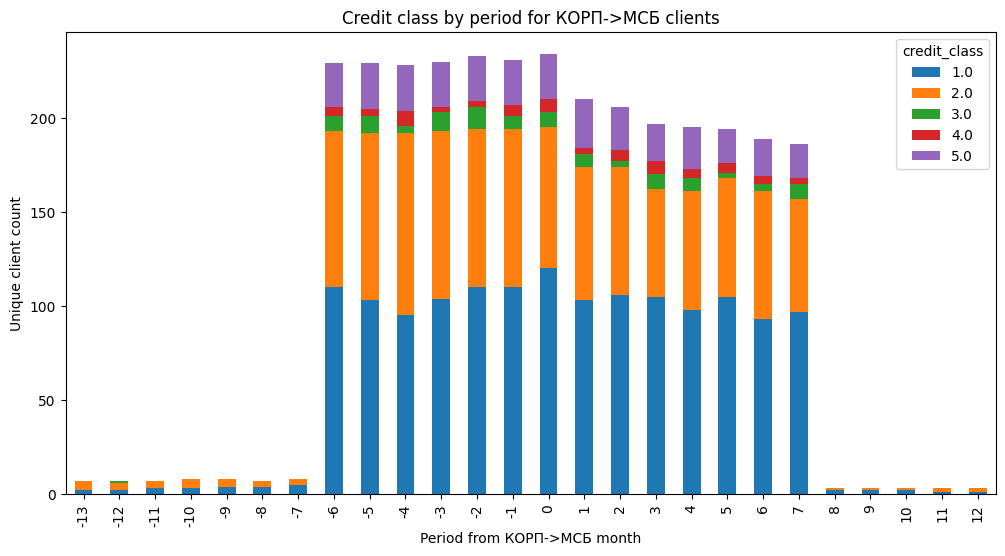

In [5]:
plot_df = hist[(hist['credit_class'].notna()) & (hist['credit_class'] != 0)].copy()

count_df = (
    plot_df.groupby(['period', 'credit_class'])['client_code']
           .nunique()
           .unstack(fill_value=0)
           .sort_index()
)

count_df.plot(kind='bar', stacked=True, figsize=(12, 6))
plt.xlabel('Period from КОРП->МСБ month')
plt.ylabel('Unique client count')
plt.title('Credit class by period for КОРП->МСБ clients')
plt.show()

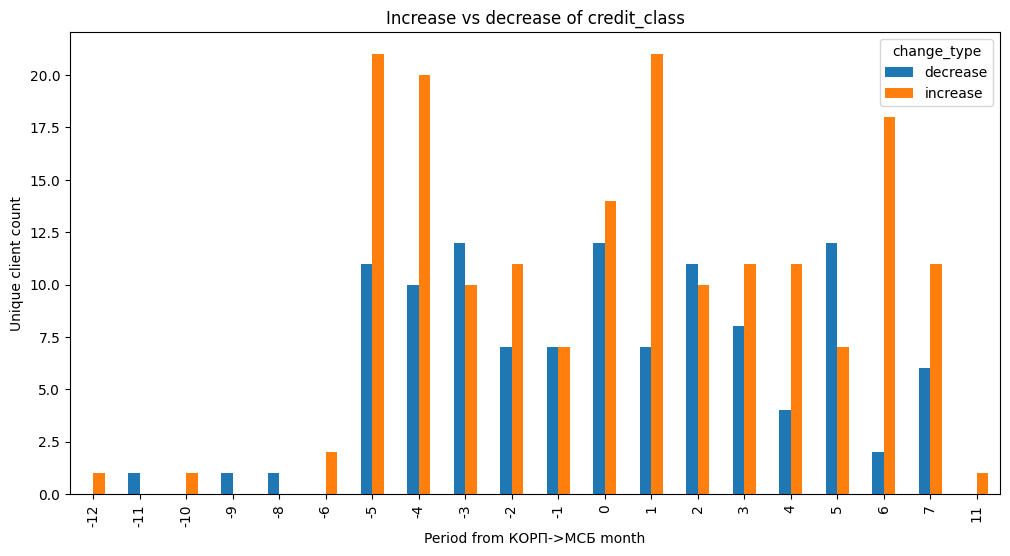

In [70]:
plot_df = hist[(hist['credit_class'].notna()) & (hist['credit_class'] != 0)].copy()
plot_df = plot_df.sort_values(['client_code', 'eomonth'])

plot_df['credit_class_change'] = plot_df.groupby('client_code')['credit_class'].diff()

plot_df['change_type'] = np.where(
    plot_df['credit_class_change'] > 0, 'increase',
    np.where(plot_df['credit_class_change'] < 0, 'decrease', 'no_change')
)

plot_df = plot_df[plot_df['change_type'].isin(['increase', 'decrease'])]

change_result = (
    plot_df.groupby(['period', 'change_type'])['client_code']
           .nunique()
           .unstack(fill_value=0)
           .sort_index()
)

change_result.plot(kind='bar', figsize=(12, 6))
plt.xlabel('Period from КОРП->МСБ month')
plt.ylabel('Unique client count')
plt.title('Increase vs decrease of credit_class')
plt.show()

# Июль

In [53]:
clients = df.loc[
    (df['eomonth'] == pd.Timestamp('2025-06-30')) &
    (df['credit_class'].isin([3, 4, 5])) &
    (df['segment'] == 'КОРП'),
    'client_code'
]
clients

232870    00126956
233250    00215306
233491    00242114
233542    00246227
233545    00246517
            ...   
258510    05305563
258744    05315177
260006    05381777
261179    05429099
262483    05479148
Name: client_code, Length: 159, dtype: str

In [57]:
pd.set_option('display.max_rows', None)
df[(df['client_code'].isin(clients))& (df['eomonth'] >= pd.Timestamp('2025-06-30'))&(df['eomonth'] <= pd.Timestamp('2025-08-30'))&(df['credit_class'] <3)]

,eomonth,client_code,segment,status,turnover_bn,turnover_y_bn,credit_class,overdue_debt_bn,loan_amount_bn,loan_rest_bn,is_group,is_official
287756,2025-07-31,00718948,МСБ,КОРП->МСБ,0.03,0.08,2.0,0.38,6.30,5.69,0,0
290792,2025-07-31,00873883,МСБ,КОРП->МСБ,0.36,21.88,0.0,0.00,18.92,0.00,0,0
300434,2025-07-31,04852109,МСБ,КОРП->МСБ,0.01,0.00,1.0,0.00,0.70,0.00,0,0
309759,2025-07-31,05429099,МСБ,КОРП->МСБ,0.00,10.68,2.0,0.00,24.00,0.00,0,0


In [58]:
pd.reset_option('display.max_rows')


In [ ]:
df[df['client_code'].isin(clients)].groupby(['status', 'eomonth'])['client_code'].nunique().unstack(fill_value=0)

eomonth,2025-01-31,2025-02-28,2025-03-31,2025-04-30,2025-05-31,2025-06-30,2025-07-31,2025-08-31,2025-09-30,2025-10-31,2025-11-30,2025-12-31,2026-01-31,2026-02-28
status,,,,,,,,,,,,,,
k_exit,0,0,0,0,0,50,0,0,0,0,0,0,0,0
k_re_exit,0,0,0,0,0,57,0,0,0,0,0,0,1,0
m_exit,0,0,0,0,0,0,0,0,1,0,2,1,0,0
m_re_entry,0,0,0,0,0,0,0,6,7,5,10,4,3,3
m_re_exit,0,0,0,0,0,0,0,4,4,3,4,4,13,0
КОРП,159,159,159,159,159,52,15,15,15,15,15,15,14,14
КОРП->МСБ,0,0,0,0,0,0,37,0,0,0,0,0,0,0
МСБ,0,0,0,0,0,0,0,27,28,32,31,36,27,30


In [ ]:
client_base[client_base['client_code'].isin(df[df['status'].isin(['k_exit','k_re_exit'])&(df['client_code'].isin(clients))]['client_code'])]['condition'].value_counts()

condition
A    106
T      1
Name: count, dtype: int64

In [ ]:
msb_acb[msb_acb['client_code'].isin(clients)].groupby(['segment', 'eomonth'])['client_code'].nunique().unstack(fill_value=0)

eomonth,2024-01-31,2024-07-31,2024-08-31,2024-09-30,2024-10-31,2024-11-30,2024-12-31,2025-01-31,2025-02-28,2025-03-31,2025-04-30,2025-05-31,2025-06-30,2025-08-31,2025-09-30,2025-10-31,2025-11-30,2025-12-31,2026-01-31,2026-02-28
segment,,,,,,,,,,,,,,,,,,,,
МСБ,34,48,26,26,22,27,23,20,17,16,13,8,4,6,11,14,20,22,22,14


# Read excels

In [ ]:
df = pd.read_excel(r'C:\Users\nzayniyev\Documents\сегментация\segmentation_data.xlsx')
df["client_code"] = df['client_code'].astype(str).str.zfill(8)
df["eomonth"] = pd.to_datetime(df["eomonth"])
df

KeyboardInterrupt: 

In [ ]:
inn = pd.read_sql(
f"""
SELECT inn, code FROM client_current cc
JOIN {table_name} y ON cc.code=client_code
"""
, conn)
inn

NameError: name 'table_name' is not defined

In [ ]:
inn.to_excel(r'C:\Users\nzayniyev\Documents\сегментация\inn.xlsx', index=False)

In [ ]:
df_jul = df[df['client_code'].isin(df[(df['status']=='КОРП->МСБ')&(df['eomonth']=='2025-07-31')]['client_code'])].reset_index(drop=True)

In [ ]:
credit_oborot = pd.read_excel(r'C:\Users\nzayniyev\Documents\сегментация\credit_oborot.xlsx')
credit_oborot["client_code"] = credit_oborot['client_code'].astype(str).str.zfill(8)
credit_oborot["eomonth"] = pd.to_datetime(credit_oborot["eomonth"])
credit_oborot['credit_oborot'] = pd.to_numeric(credit_oborot['credit_oborot'], errors='coerce', downcast='integer')
credit_oborot

C:\Users\nzayniyev\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\pandas\core\dtypes\cast.py:355: RuntimeWarning: invalid value encountered in cast
  new_result = trans(result).astype(dtype)


,eomonth,client_code,credit_oborot
0,2025-01-31,00453974,1.857493e+07
1,2025-01-31,05354418,1.220355e+09
2,2025-01-31,07021322,2.484002e+08
3,2025-01-31,00849628,5.075386e+08
4,2025-01-31,05653939,3.317090e+08
...,...,...,...
442854,2024-09-30,00463389,1.358467e+08
442855,2024-10-31,00914512,8.921500e+07
442856,2024-11-30,00463389,1.340639e+08
442857,2024-12-31,00463389,1.091700e+06


In [ ]:
credit_oborot = credit_oborot.sort_values(["client_code", "eomonth"]).copy()
credit_oborot["eomonth"] = pd.to_datetime(credit_oborot["eomonth"])

def add_full_months(g):
    client = g.name  # current client_code from groupby

    full_idx = pd.date_range(
        start=g["eomonth"].min(),
        end=g["eomonth"].max(),
        freq="ME"
    )

    g = (
        g.set_index("eomonth")
         .reindex(full_idx)
         .rename_axis("eomonth")
         .reset_index()
    )

    g["client_code"] = client
    g["credit_oborot"] = g["credit_oborot"].fillna(0)

    return g

credit_oborot = (
    credit_oborot.groupby("client_code", group_keys=False)
    .apply(add_full_months)
    .reset_index(drop=True)
)

credit_oborot["credit_oborot_y_bn"] = (
    credit_oborot.groupby("client_code")["credit_oborot"]
    .transform(lambda s: (s.rolling(12, min_periods=12).sum() / 1e9).round(2))
)

credit_oborot = credit_oborot[[
    "client_code",
    "eomonth",
    "credit_oborot_y_bn",
]]
credit_oborot = credit_oborot.reset_index(drop=True)
credit_oborot["credit_oborot_y_bn"] = credit_oborot["credit_oborot_y_bn"].fillna(0)
credit_oborot

,client_code,eomonth,credit_oborot_y_bn
0,00000450,2025-01-31,0.0
1,00000450,2025-02-28,0.0
2,00000450,2025-03-31,0.0
3,00000450,2025-04-30,0.0
4,00000450,2025-05-31,0.0
...,...,...,...
525844,07412931,2026-02-28,0.0
525845,07413146,2026-02-28,0.0
525846,07413148,2026-02-28,0.0
525847,07413530,2026-02-28,0.0


In [ ]:
df_jul = pd.merge(df_jul, credit_oborot, how='left', on=['eomonth', 'client_code'])
df_jul

,eomonth,client_code,segment,status,credit_class,overdue_debt_bn,credit_oborot_y_bn
0,2025-01-31,00101007,КОРП,current,NaN,NaN,20.75
1,2025-02-28,00101007,КОРП,current,NaN,NaN,27.49
2,2025-03-31,00101007,КОРП,current,NaN,NaN,27.44
3,2025-04-30,00101007,КОРП,current,NaN,NaN,28.14
4,2025-05-31,00101007,КОРП,current,NaN,NaN,28.55
...,...,...,...,...,...,...,...
7252,2025-10-31,07234185,МСБ,current,NaN,NaN,0.00
7253,2025-11-30,07234185,МСБ,current,NaN,NaN,0.00
7254,2025-12-31,07234185,МСБ,current,NaN,NaN,0.00
7255,2026-01-31,07234185,МСБ,current,NaN,NaN,0.00


In [ ]:
# turnover_dksi_jul = pd.read_excel(r'C:\Users\nzayniyev\Documents\сегментация\turnover_dksi_jul.xlsx')
# turnover_dksi_jul["client_code"] = turnover_dksi_jul['client_code'].astype(str).str.zfill(8)
# turnover_dksi_jul["eomonth"] = pd.to_datetime(turnover_dksi_jul["eomonth"])
# turnover_dksi_jul['credit_oborot'] = pd.to_numeric(turnover_dksi_jul['credit_oborot'], errors='coerce', downcast='integer')
# turnover_dksi_jul

In [ ]:
# df_jul = pd.merge(df_jul, turnover_dksi, how='left', on=['eomonth', 'client_code'])
# df_jul

In [ ]:
external_turnover_24 = pd.read_excel(r'C:\Users\nzayniyev\Documents\сегментация\ihamkor_revenue.xlsx', sheet_name ='2024')
external_turnover_24 = external_turnover_24.drop(columns=['company_name'])
external_turnover_24["inn"] = external_turnover_24['inn'].astype(str).str.zfill(9)
external_turnover_24['revenue_2024'] = pd.to_numeric(external_turnover_24['revenue_2024'], errors='coerce', downcast='integer')
external_turnover_24["revenue_2024_bn"] = (external_turnover_24["revenue_2024"]/ 1e9).round(2)
external_turnover_24 = external_turnover_24.drop(columns=['revenue_2024'])
external_turnover_24

,inn,revenue_2024_bn
0,300939824,232894.57
1,306244704,139611.42
2,308425864,94150.69
3,200244767,53540.31
4,309702449,42800.00
...,...,...
2995,203202319,63.75
2996,305936777,63.74
2997,309489792,63.73
2998,306137987,63.71


In [ ]:
external_turnover_25 = pd.read_excel(r'C:\Users\nzayniyev\Documents\сегментация\ihamkor_revenue.xlsx', sheet_name ='2025')
external_turnover_25 = external_turnover_25.drop(columns=['company_name'])
external_turnover_25["inn"] = external_turnover_25['inn'].astype(str).str.zfill(9)
external_turnover_25['revenue_2025'] = pd.to_numeric(external_turnover_25['revenue_2025'], errors='coerce', downcast='integer')
external_turnover_25["revenue_2025_bn"] = (external_turnover_25["revenue_2025"]/ 1e9).round(2)
external_turnover_25 = external_turnover_25.drop(columns=['revenue_2025'])
external_turnover_25

,inn,revenue_2025_bn
0,308425864,135809.98
1,200244767,53634.17
2,309702449,52057.30
3,310960914,50719.91
4,202328794,50425.73
...,...,...
13995,310832676,15.24
13996,305966391,15.23
13997,207077068,15.23
13998,200954833,15.23


In [ ]:
inn = pd.read_excel(r'C:\Users\nzayniyev\Documents\сегментация\inn.xlsx')
inn["client_code"] = inn['client_code'].astype(str).str.zfill(8)
inn["inn"] = inn['inn'].astype(str).str.zfill(9)
inn.head()

,inn,client_code
0,200836354.0,00000450
1,111111122.0,00009002
2,202817329.0,03987039
3,303968651.0,00626485
4,301820584.0,04894772


In [ ]:
df_jul = pd.merge(df_jul, inn, how='left', on=['client_code'])
df_jul.head()

,eomonth,client_code,segment,status,credit_class,overdue_debt_bn,credit_oborot_y_bn,inn
0,2025-01-31,00101007,КОРП,current,NaN,NaN,20.75,201051699.0
1,2025-02-28,00101007,КОРП,current,NaN,NaN,27.49,201051699.0
2,2025-03-31,00101007,КОРП,current,NaN,NaN,27.44,201051699.0
3,2025-04-30,00101007,КОРП,current,NaN,NaN,28.14,201051699.0
4,2025-05-31,00101007,КОРП,current,NaN,NaN,28.55,201051699.0


In [ ]:
df_jul = pd.merge(df_jul, external_turnover_24, how='left', on=['inn'])

In [ ]:
df_jul = pd.merge(df_jul, external_turnover_25, how='left', on=['inn'])
df_jul

,eomonth,client_code,segment,status,credit_class,overdue_debt_bn,credit_oborot_y_bn,inn,revenue_2024_bn,revenue_2025_bn
0,2025-01-31,00101007,КОРП,current,NaN,NaN,20.75,201051699.0,NaN,NaN
1,2025-02-28,00101007,КОРП,current,NaN,NaN,27.49,201051699.0,NaN,NaN
2,2025-03-31,00101007,КОРП,current,NaN,NaN,27.44,201051699.0,NaN,NaN
3,2025-04-30,00101007,КОРП,current,NaN,NaN,28.14,201051699.0,NaN,NaN
4,2025-05-31,00101007,КОРП,current,NaN,NaN,28.55,201051699.0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
7252,2025-10-31,07234185,МСБ,current,NaN,NaN,0.00,312095595.0,NaN,NaN
7253,2025-11-30,07234185,МСБ,current,NaN,NaN,0.00,312095595.0,NaN,NaN
7254,2025-12-31,07234185,МСБ,current,NaN,NaN,0.00,312095595.0,NaN,NaN
7255,2026-01-31,07234185,МСБ,current,NaN,NaN,0.00,312095595.0,NaN,NaN


In [ ]:
df_jul["external_revenue"] = df_jul["revenue_2025_bn"].combine_first(df_jul["revenue_2024_bn"])
df_jul = df_jul.drop(columns=['inn','revenue_2025_bn','revenue_2024_bn'])

In [ ]:
df_jul["credit_oborot_y_bn"] = df_jul["credit_oborot_y_bn"].fillna(0)
df_jul["overdue_debt_bn"] = df_jul["overdue_debt_bn"].fillna(0)
df_jul["external_revenue"] = df_jul["external_revenue"].fillna(0)
df_jul

,eomonth,client_code,segment,status,credit_class,overdue_debt_bn,credit_oborot_y_bn,external_revenue
0,2025-01-31,00101007,КОРП,current,NaN,0.0,20.75,0.0
1,2025-02-28,00101007,КОРП,current,NaN,0.0,27.49,0.0
2,2025-03-31,00101007,КОРП,current,NaN,0.0,27.44,0.0
3,2025-04-30,00101007,КОРП,current,NaN,0.0,28.14,0.0
4,2025-05-31,00101007,КОРП,current,NaN,0.0,28.55,0.0
...,...,...,...,...,...,...,...,...
7252,2025-10-31,07234185,МСБ,current,NaN,0.0,0.00,0.0
7253,2025-11-30,07234185,МСБ,current,NaN,0.0,0.00,0.0
7254,2025-12-31,07234185,МСБ,current,NaN,0.0,0.00,0.0
7255,2026-01-31,07234185,МСБ,current,NaN,0.0,0.00,0.0


In [ ]:
df_jul.loc[df_jul["eomonth"] == df_jul["eomonth"].max(), "status"] = "current"

In [ ]:
# df_jul['segment_status'] = np.where(
#     df_jul['status'].isin(['current', 'КОРП->МСБ', 'МСБ->КОРП']),
#     np.where(df_jul['status'].eq('current'), df_jul['segment'], df_jul['status']),
#     df_jul['segment'] + ' | ' + df_jul['status']
# )
# df_jul['segment_status'].unique()

# кредитный оборот падает

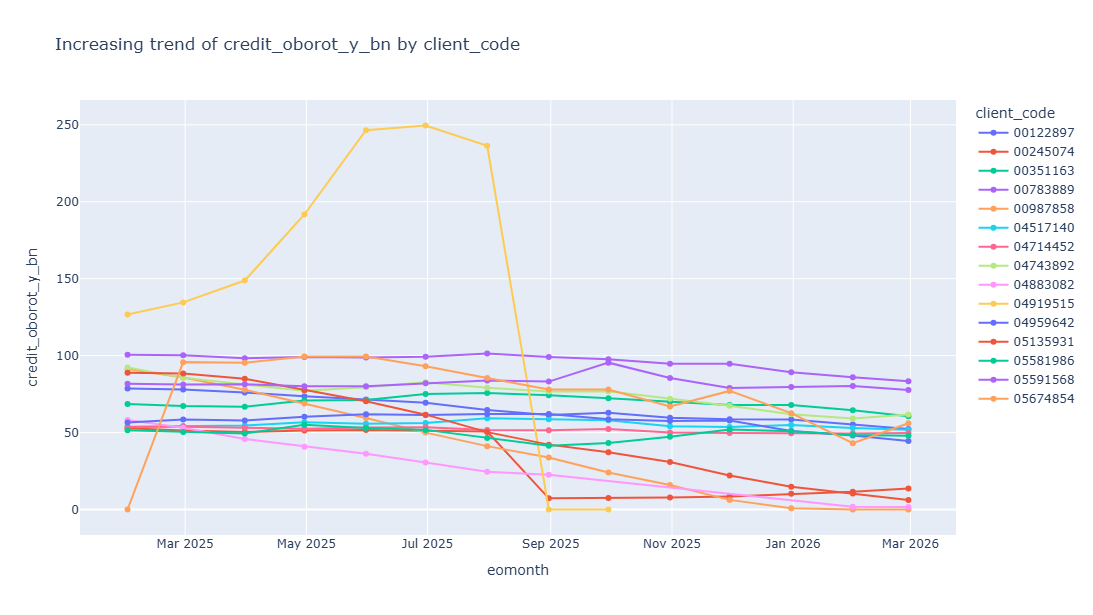

In [ ]:
# sort for clean plotting
plot_df = df_jul.sort_values(['client_code', 'eomonth']).copy()
#plot_df = plot_df[plot_df['eomonth'] <= '2026-02-28'].copy()

# keep only client_code with credit_oborot_y_bn > 50 in at least one eomonth
valid_clients = (
    plot_df.groupby('client_code')['credit_oborot_y_bn']
    .apply(lambda s: (s > 50).any())
)

valid_clients = valid_clients[valid_clients].index

plot_df = plot_df[plot_df['client_code'].isin(valid_clients)]

# find client_code with decreasing trend
deccreasing_clients = []

for client_code, group in plot_df.groupby('client_code'):
    group = group.sort_values('eomonth')
    y = group['credit_oborot_y_bn'].fillna(0).values
    
    # need at least 2 points to calculate a slope
    if len(y) >= 2:
        x = np.arange(len(y))
        slope = np.polyfit(x, y, 1)[0]
        if slope < 0:
            deccreasing_clients.append(client_code)

# keep only increasing-trend clients
plot_df = plot_df[plot_df['client_code'].isin(deccreasing_clients)].copy()

# make sure date column is datetime
plot_df['eomonth'] = pd.to_datetime(plot_df['eomonth'])

# interactive plot
fig = px.line(
    plot_df,
    x='eomonth',
    y='credit_oborot_y_bn',
    color='client_code',
    markers=True,
    title='Increasing trend of credit_oborot_y_bn by client_code',
    hover_data={
        'client_code': True,
        'eomonth': True,
        'credit_oborot_y_bn': ':.2f'
    }
)

fig.update_layout(
    xaxis_title='eomonth',
    yaxis_title='credit_oborot_y_bn',
    hovermode='closest',
    width=1100,
    height=600
)

fig.show()

# растущий тренд задолженности

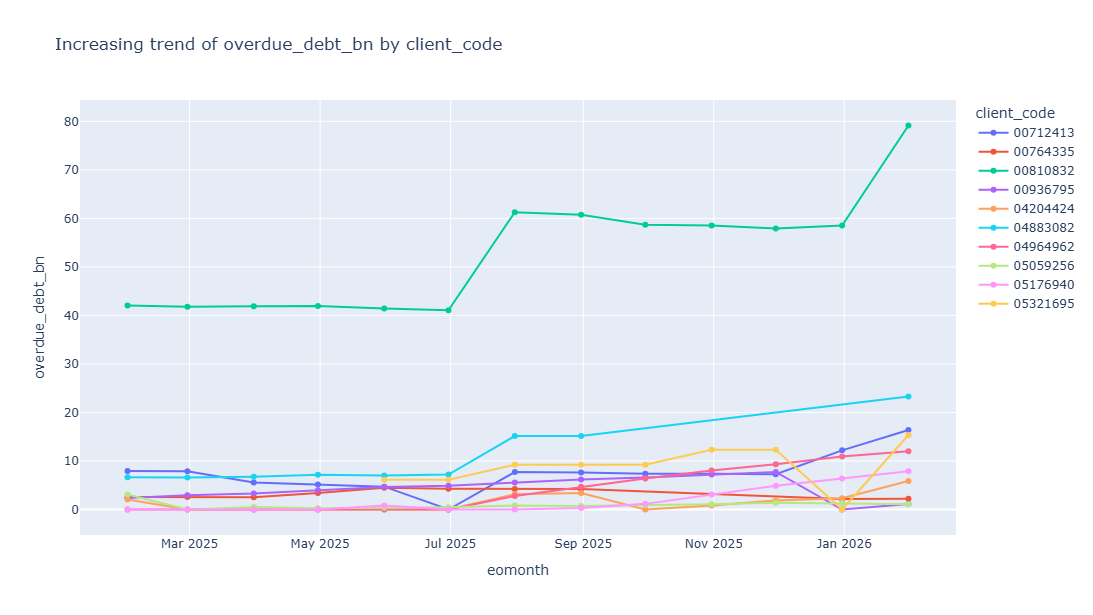

In [ ]:
# sort for clean plotting
plot_df = df_jul.sort_values(['client_code', 'eomonth']).copy()
plot_df = plot_df[plot_df['eomonth'] < '2026-02-28'].copy()

# keep only client_code with overdue_debt_bn > 3 in at least one eomonth
valid_clients = (
    plot_df.groupby('client_code')['overdue_debt_bn']
    .apply(lambda s: (s > 3).any())
)
valid_clients = valid_clients[valid_clients].index
#valid_clients = valid_clients[~valid_clients.isin(['00810832'])]

plot_df = plot_df[plot_df['client_code'].isin(valid_clients)]

# remove client_code with overdue_debt_bn = 0 in at least 2 eomonth after 30.06.2025
zero_counts = (
    plot_df[plot_df['eomonth'] > '2025-06-30']
    .groupby('client_code')['overdue_debt_bn']
    .apply(lambda s: (s == 0).sum())
)

clients_to_keep = zero_counts[zero_counts < 2].index

plot_df = plot_df[plot_df['client_code'].isin(clients_to_keep)]

# find client_code with increasing trend
increasing_clients = []

for client_code, group in plot_df.groupby('client_code'):
    group = group.sort_values('eomonth')
    y = group['overdue_debt_bn'].fillna(0).values
    
    # need at least 2 points to calculate a slope
    if len(y) >= 2:
        x = np.arange(len(y))
        slope = np.polyfit(x, y, 1)[0]
        if slope > 0:
            increasing_clients.append(client_code)

# keep only increasing-trend clients
plot_df = plot_df[plot_df['client_code'].isin(increasing_clients)].copy()

# make sure date column is datetime
plot_df['eomonth'] = pd.to_datetime(plot_df['eomonth'])

# interactive plot
fig = px.line(
    plot_df,
    x='eomonth',
    y='overdue_debt_bn',
    color='client_code',
    markers=True,
    title='Increasing trend of overdue_debt_bn by client_code',
    hover_data={
        'client_code': True,
        'eomonth': True,
        'overdue_debt_bn': ':.2f'
    }
)

fig.update_layout(
    xaxis_title='eomonth',
    yaxis_title='overdue_debt_bn',
    hovermode='closest',
    width=1100,
    height=600
)

fig.show()

In [ ]:
overdue_debt = plot_df.pivot(index=['client_code'], columns='eomonth', values=['overdue_debt_bn','segment']).swaplevel(0, 1, axis=1)
overdue_debt = overdue_debt.loc[:, [(m, v) for m in sorted(overdue_debt.columns.get_level_values(0).unique())
                        for v in ['overdue_debt_bn', 'segment']
                        if (m, v) in overdue_debt.columns]
                    ]
overdue_debt.head()

eomonth          2025-01-31              2025-02-28              2025-03-31  \
            overdue_debt_bn segment overdue_debt_bn segment overdue_debt_bn   
client_code                                                                   
00712413               7.93    КОРП            7.88    КОРП            5.56   
00764335               2.58    КОРП            2.56    КОРП            2.51   
00810832              42.03    КОРП           41.77    КОРП           41.89   
00936795               2.36    КОРП            2.95    КОРП            3.31   
04204424               2.06    КОРП             0.0    КОРП             0.0   

eomonth                  2025-04-30              2025-05-31          ...  \
            segment overdue_debt_bn segment overdue_debt_bn segment  ...   
client_code                                                          ...   
00712413       КОРП            5.17    КОРП            4.71    КОРП  ...   
00764335       КОРП            3.41    КОРП            4.47    КОРП  ...   
00810832       КОРП           41.95    КОРП           41.42    КОРП  ...   
00936795       КОРП            3.99    КОРП            4.62    КОРП  ...   
04204424       КОРП             0.0    КОРП             0.0    КОРП  ...   

eomonth          2025-09-30              2025-10-31              2025-11-30  \
            overdue_debt_bn segment overdue_debt_bn segment overdue_debt_bn   
client_code                                                                   
00712413               7.39     МСБ            7.36     МСБ            7.28   
00764335                NaN     NaN             NaN     NaN             NaN   
00810832              58.71     МСБ           58.51     МСБ           57.91   
00936795               6.58     МСБ            7.19     МСБ            7.75   
04204424                0.0     МСБ            0.82     МСБ            1.87   

eomonth                  2025-12-31              2026-01-31          
            segment overdue_debt_bn segment overdue_debt_bn segment  
client_code                                                          
00712413        МСБ           12.19     МСБ            16.4     МСБ  
00764335        NaN            2.16     МСБ            2.19     МСБ  
00810832        МСБ           58.51     МСБ           79.14     МСБ  
00936795        МСБ             0.0     МСБ            1.15     МСБ  
04204424        МСБ            2.33     МСБ            5.89     МСБ  

[5 rows x 26 columns]

In [ ]:
overdue_debt.to_excel(r'C:\Users\nzayniyev\Documents\сегментация\result\overdue_debt.xlsx')

In [ ]:
df_jul[
    df_jul['client_code'].isin(overdue_debt.index)
].loc[
    lambda d: d.groupby('client_code')['credit_oborot_y_bn'].idxmax()
]

,eomonth,client_code,segment,status,credit_class,overdue_debt_bn,credit_oborot_y_bn,external_revenue
1207,2026-01-31,00712413,МСБ,current,2.0,16.40,12.23,0.0
1376,2025-06-30,00764335,КОРП,current,2.0,4.26,2.83,0.0
1618,2025-01-31,00810832,КОРП,current,2.0,42.03,1.91,0.0
2036,2025-01-31,00936795,КОРП,current,2.0,2.36,24.99,0.0
2470,2025-08-31,04204424,МСБ,current,2.0,3.40,18.53,0.0
3533,2025-01-31,04883082,КОРП,current,1.0,6.63,58.17,0.0
3803,2025-08-31,04964962,МСБ,current,2.0,4.67,1.26,0.0
4045,2025-12-31,05059256,МСБ,current,2.0,1.30,14.45,0.0
4436,2025-08-31,05176940,МСБ,current,2.0,0.31,31.74,0.0
4801,2025-05-31,05321695,КОРП,new_entry,2.0,6.14,0.00,0.0


# переходящие в npl

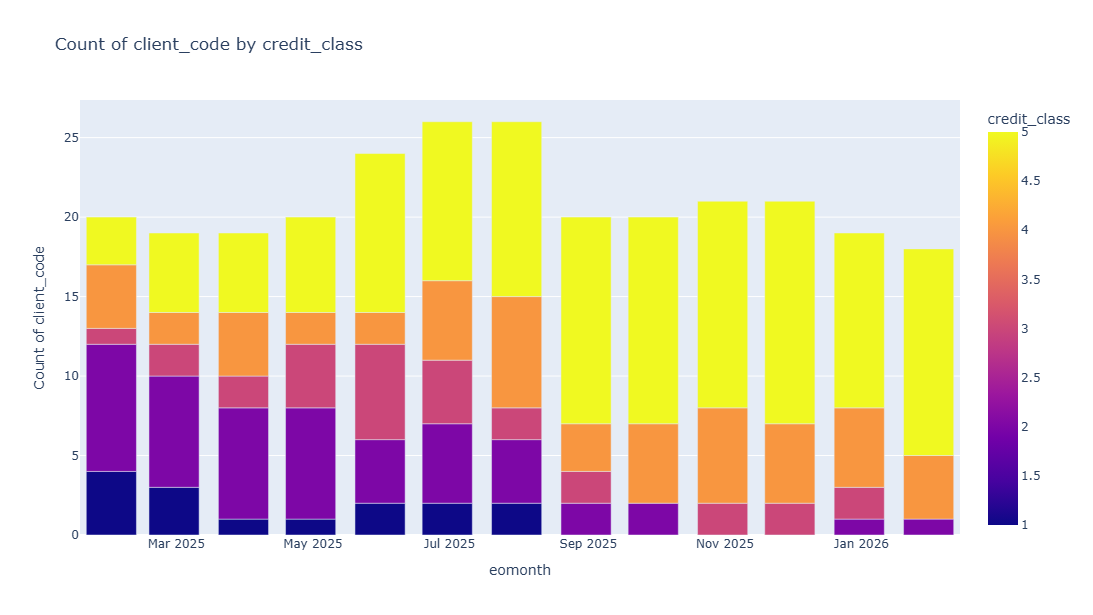

In [ ]:
# sort for clean plotting
plot_df = df_jul.sort_values(['client_code', 'eomonth']).copy()
plot_df = plot_df[plot_df['eomonth'] < '2026-02-28'].copy()

# keep only client_code with credit_class > 3 in at least one eomonth

valid_clients = (
    plot_df[plot_df['eomonth'] > '2025-06-30']
    .groupby('client_code')['credit_class']
    .apply(lambda s: (s > 3).any())
)
valid_clients = valid_clients[valid_clients].index

plot_df = plot_df[plot_df['client_code'].isin(valid_clients)]

# find client_code with increasing trend
increasing_clients = []

for client_code, group in plot_df.groupby('client_code'):
    group = group.sort_values('eomonth')
    y = group['credit_class'].fillna(0).values
    
    # need at least 2 points to calculate a slope
    if len(y) >= 2:
        x = np.arange(len(y))
        slope = np.polyfit(x, y, 1)[0]
        if slope > 0:
            increasing_clients.append(client_code)

# keep only increasing-trend clients
plot_df = plot_df[plot_df['client_code'].isin(increasing_clients)].copy()

# make sure date column is datetime
plot_df['eomonth'] = pd.to_datetime(plot_df['eomonth'])

# count unique client_code by eomonth and credit_class
count_df = (
    plot_df.groupby(['eomonth', 'credit_class'])['client_code']
    .nunique()
    .reset_index(name='client_count')
)

# stacked column chart
fig = px.bar(
    count_df,
    x='eomonth',
    y='client_count',
    color='credit_class',
    title='Count of client_code by credit_class',
    hover_data={
        'eomonth': True,
        'credit_class': True,
        'client_count': True
    }
)

fig.update_layout(
    barmode='stack',
    xaxis_title='eomonth',
    yaxis_title='Count of client_code',
    width=1100,
    height=600
)

fig.show()

In [ ]:
npl = plot_df.pivot(index=['client_code'], columns='eomonth', values=['credit_class','segment']).swaplevel(0, 1, axis=1)
npl = npl.loc[:, [(m, v) for m in sorted(npl.columns.get_level_values(0).unique())
                        for v in ['credit_class', 'segment']
                        if (m, v) in npl.columns]
                    ]
npl.head()

eomonth       2025-01-31           2025-02-28           2025-03-31          \
            credit_class segment credit_class segment credit_class segment   
client_code                                                                  
00215306             4.0    КОРП          4.0    КОРП          4.0    КОРП   
00293483             2.0    КОРП          3.0    КОРП          4.0    КОРП   
00462215             5.0    КОРП          5.0    КОРП          5.0    КОРП   
00623035             2.0    КОРП          2.0    КОРП          2.0    КОРП   
00634025             2.0    КОРП          2.0    КОРП          NaN     NaN   

eomonth       2025-04-30           2025-05-31          ...   2025-09-30  \
            credit_class segment credit_class segment  ... credit_class   
client_code                                            ...                
00215306             5.0    КОРП          5.0    КОРП  ...          5.0   
00293483             3.0    КОРП          4.0    КОРП  ...          5.0   
00462215             5.0    КОРП          5.0    КОРП  ...          NaN   
00623035             2.0    КОРП          2.0    КОРП  ...          2.0   
00634025             NaN     NaN          NaN     NaN  ...          5.0   

eomonth               2025-10-31           2025-11-30           2025-12-31  \
            segment credit_class segment credit_class segment credit_class   
client_code                                                                  
00215306        МСБ          4.0     МСБ          5.0     МСБ          5.0   
00293483        МСБ          NaN     NaN          NaN     NaN          NaN   
00462215        NaN          NaN     NaN          5.0     МСБ          5.0   
00623035        МСБ          3.0     МСБ          3.0     МСБ          3.0   
00634025        МСБ          5.0     МСБ          5.0     МСБ          2.0   

eomonth               2026-01-31          
            segment credit_class segment  
client_code                               
00215306        МСБ          5.0     МСБ  
00293483        NaN          NaN     NaN  
00462215        МСБ          5.0     МСБ  
00623035        МСБ          4.0     МСБ  
00634025        МСБ          2.0     МСБ  

[5 rows x 26 columns]

In [ ]:
npl.to_excel(r'C:\Users\nzayniyev\Documents\сегментация\result\npl.xlsx')

In [ ]:
df_jul[
    df_jul['client_code'].isin(npl.index)
].loc[
    lambda d: d.groupby('client_code')['credit_oborot_y_bn'].idxmax()
]

,eomonth,client_code,segment,status,credit_class,overdue_debt_bn,credit_oborot_y_bn,external_revenue
102,2025-01-31,00215306,КОРП,current,4.0,2.93,1.23,0.0
322,2025-01-31,00293483,КОРП,current,2.0,11.53,0.43,0.0
735,2025-05-31,00462215,КОРП,current,5.0,0.00,0.65,0.0
1027,2025-02-28,00623035,КОРП,current,2.0,1.31,10.06,0.0
1058,2025-08-31,00634025,МСБ,current,3.0,1.38,0.08,0.0
1226,2025-04-30,00719010,КОРП,current,1.0,4.78,13.36,0.0
1322,2025-07-31,00752875,МСБ,КОРП->МСБ,5.0,0.00,0.37,0.0
1505,2026-01-31,00786556,МСБ,current,5.0,0.00,8.47,0.0
1520,2025-01-31,00794750,КОРП,current,1.0,0.00,0.63,0.0
1774,2025-07-31,00852266,МСБ,КОРП->МСБ,5.0,0.94,0.16,0.0


# exit

In [ ]:
exit = df_jul.copy()

exit = (
    exit.sort_values(['client_code', 'eomonth'])
       .groupby('client_code', as_index=False)
       .tail(1)
)

exit = exit[exit['status'].isin(['exit', 're_exit'])]

exit

,eomonth,client_code,segment,status,credit_class,overdue_debt_bn,credit_oborot_y_bn,external_revenue
37,2025-10-31,00112421,МСБ,exit,NaN,0.0,0.0,0.0
73,2025-08-31,00129640,МСБ,exit,NaN,0.0,0.0,0.0
238,2025-11-30,00251801,МСБ,exit,NaN,0.0,0.0,0.0
330,2025-09-30,00293483,МСБ,exit,5.0,0.0,0.0,0.0
367,2025-09-30,00312122,МСБ,exit,NaN,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...
7061,2025-09-30,07183631,МСБ,exit,NaN,0.0,0.0,0.0
7071,2025-10-31,07189425,МСБ,exit,NaN,0.0,0.0,0.0
7097,2026-01-31,07192253,МСБ,re_exit,NaN,0.0,0.0,0.0
7199,2025-11-30,07211721,МСБ,exit,NaN,0.0,0.0,0.0


In [ ]:
exit.to_excel(r'C:\Users\nzayniyev\Documents\сегментация\result\exit.xlsx')

In [ ]:
exit_turnover = df_jul[
    df_jul['client_code'].isin(exit['client_code'])
].loc[
    lambda d: d.groupby('client_code')['credit_oborot_y_bn'].idxmax()
]
exit_turnover.to_excel(r'C:\Users\nzayniyev\Documents\сегментация\result\exit_turnover.xlsx')

In [ ]:
df_jul[df_jul['client_code']=='04919515']

,eomonth,client_code,segment,status,credit_class,overdue_debt_bn,credit_oborot_y_bn,external_revenue
3658,2025-01-31,04919515,КОРП,current,NaN,0.0,126.70,0.0
3659,2025-02-28,04919515,КОРП,current,NaN,0.0,134.62,0.0
3660,2025-03-31,04919515,КОРП,current,NaN,0.0,148.82,0.0
3661,2025-04-30,04919515,КОРП,current,NaN,0.0,191.75,0.0
3662,2025-05-31,04919515,КОРП,current,NaN,0.0,246.57,0.0
3663,2025-06-30,04919515,КОРП,current,NaN,0.0,249.58,0.0
3664,2025-07-31,04919515,МСБ,КОРП->МСБ,NaN,0.0,236.41,0.0
3665,2025-08-31,04919515,МСБ,current,NaN,0.0,0.00,0.0
3666,2025-09-30,04919515,МСБ,exit,NaN,0.0,0.00,0.0


In [ ]:
df_jul['client_code'].unique()

<StringArray>
['00101007', '00101422', '00112421', '00122897', '00122962', '00129640',
 '00147904', '00191721', '00215306', '00224423',
 ...
 '07202822', '07206934', '07208124', '07211721', '07212805', '07215004',
 '07215634', '07221000', '07227845', '07234185']
Length: 563, dtype: str

# New

In [ ]:
new_clients = df_jul[(df_jul['eomonth'] < '2025-07-31')&
                        (df_jul['status'].isin(["new_entry", "re_entry", "МСБ->КОРП"]))]
new_clients = df_jul[df_jul['client_code'].isin(new_clients['client_code'])]
new_clients

,eomonth,client_code,segment,status,credit_class,overdue_debt_bn,credit_oborot_y_bn,external_revenue
240,2025-02-28,00256481,КОРП,МСБ->КОРП,NaN,0.0,0.0,0.0
281,2025-02-28,00277660,МСБ,new_entry,NaN,0.0,0.0,0.0
283,2025-04-30,00277660,КОРП,МСБ->КОРП,NaN,0.0,0.0,0.0
384,2025-04-30,00331396,КОРП,re_entry,NaN,0.0,0.0,0.0
573,2025-02-28,00420303,КОРП,МСБ->КОРП,NaN,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...
7212,2025-04-30,07215004,КОРП,new_entry,NaN,0.0,0.0,0.0
7223,2025-04-30,07215634,КОРП,new_entry,NaN,0.0,0.0,0.0
7234,2025-04-30,07221000,КОРП,new_entry,NaN,0.0,0.0,0.0
7242,2025-04-30,07227845,КОРП,new_entry,NaN,0.0,0.0,0.0


In [ ]:
new_clients = new_clients.pivot(index=['client_code'], columns='eomonth', values=['status','segment']).swaplevel(0, 1, axis=1)
new_clients = new_clients.loc[:, [(m, v) for m in sorted(new_clients.columns.get_level_values(0).unique())
                        for v in ['status', 'segment']
                        if (m, v) in new_clients.columns]
                    ]
new_clients.head()

eomonth     2025-02-28         2025-03-31         2025-04-30          \
                status segment     status segment     status segment   
client_code                                                            
00256481     МСБ->КОРП    КОРП        NaN     NaN        NaN     NaN   
00277660     new_entry     МСБ        NaN     NaN  МСБ->КОРП    КОРП   
00331396           NaN     NaN        NaN     NaN   re_entry    КОРП   
00420303     МСБ->КОРП    КОРП        NaN     NaN        NaN     NaN   
00423778           NaN     NaN  new_entry    КОРП        NaN     NaN   

eomonth     2025-05-31         2025-06-30          
                status segment     status segment  
client_code                                        
00256481           NaN     NaN        NaN     NaN  
00277660           NaN     NaN        NaN     NaN  
00331396           NaN     NaN        NaN     NaN  
00420303           NaN     NaN        NaN     NaN  
00423778           NaN     NaN        NaN     NaN

In [ ]:
new_clients.to_excel(r'C:\Users\nzayniyev\Documents\сегментация\result\new_clients.xlsx')

In [ ]:
new_clients = df_jul[
    (df_jul['eomonth'] < '2025-07-31') &
    (df_jul['status'].isin(["new_entry", "re_entry", "МСБ->КОРП"]))
]

status_counts = (
    new_clients.groupby('status')['client_code']
    .nunique()
    .reset_index(name='client_code_count')
)

status_counts

,status,client_code_count
0,new_entry,78
1,re_entry,13
2,МСБ->КОРП,47


In [ ]:
new_clients_turnover = df_jul[
    df_jul['client_code'].isin(new_clients.index)
].loc[
    lambda d: d.groupby('client_code')['credit_oborot_y_bn'].idxmax()
]
new_clients_turnover
new_clients_turnover.to_excel(r'C:\Users\nzayniyev\Documents\сегментация\result\new_clients_turnover.xlsx')

In [ ]:
df

,eomonth,client_code,segment,status,credit_class,overdue_debt_bn
0,2025-01-31,00000450,МСБ,current,NaN,NaN
1,2025-02-28,00000450,МСБ,current,NaN,NaN
2,2025-03-31,00000450,МСБ,current,NaN,NaN
3,2025-04-30,00000450,МСБ,current,NaN,NaN
4,2025-05-31,00000450,МСБ,current,NaN,NaN
...,...,...,...,...,...,...
697343,2026-02-28,07412931,МСБ,new_entry,NaN,NaN
697344,2026-02-28,07412974,МСБ,new_entry,NaN,NaN
697345,2026-02-28,07413034,МСБ,new_entry,NaN,NaN
697346,2026-02-28,07413148,МСБ,new_entry,NaN,NaN


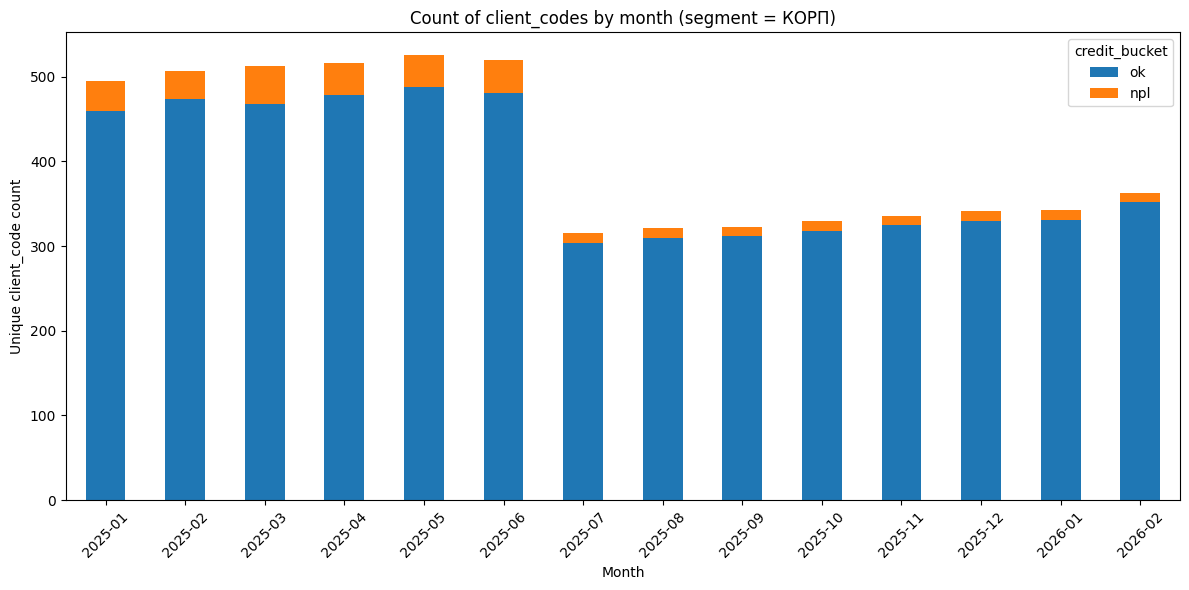

In [ ]:
tmp = df.copy()

# only КОРП
tmp = tmp[tmp['segment'].eq('КОРП')].copy()

# parse month
tmp['eomonth'] = pd.to_datetime(tmp['eomonth'], errors='coerce')
tmp = tmp[tmp['eomonth'].notna()].copy()

# bucket credit classes
tmp['credit_bucket'] = tmp['credit_class'].map({
    1: 'ok', 2: 'ok', 3: 'ok',
    4: 'npl', 5: 'npl',
    1.0: 'ok', 2.0: 'ok', 3.0: 'ok',
    4.0: 'npl', 5.0: 'npl'
})

tmp = tmp[tmp['credit_bucket'].notna()].copy()

# month label
tmp['month'] = tmp['eomonth'].dt.strftime('%Y-%m')

# count unique client_code by month and bucket
count_df = (
    tmp.groupby(['month', 'credit_bucket'])['client_code']
       .nunique()
       .unstack(fill_value=0)
       .reindex(columns=['ok', 'npl'], fill_value=0)
       .sort_index()
)

# plot counts
ax = count_df.plot(kind='bar', stacked=True, figsize=(12, 6))
ax.set_title('Count of client_codes by month (segment = КОРП)')
ax.set_xlabel('Month')
ax.set_ylabel('Unique client_code count')
ax.legend(title='credit_bucket')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
tmp = df.copy()

tmp['eomonth'] = pd.to_datetime(tmp['eomonth'], errors='coerce')

result = tmp[
    (tmp['segment'].eq('КОРП')) &
    (tmp['eomonth'].eq(pd.Timestamp('2025-07-31'))) &
    (tmp['status'].eq('exit'))
]

result['client_code'].nunique()

23